## Predicting Acute Food Insecurity Risk in Kenyan Counties using Climate and Market Signals

**Author:** Data Alchemists

**Program:** Moringa School - Data Science Capstone Project

**Date:** June-July 2026

---

### Project Overview

Kenya's smallholder farmers and pastoralists face persistent food insecurity driven by rainfall failure and soaring staple food prices. This notebook builds a **binary classification model** that predicts whether a county in Kenya will reach **IPC Phase 3 (Crisis) or worse** in a given month, using satellite-derived rainfall anomalies (CHIRPS) and WFP food price records as **leading (lagged) indicators**.

The model is designed to support Kenya's **National Drought Management Authority (NDMA)** in issuing early warnings before official IPC classifications are published.

---

### CRISP-DM Structure

| Phase | Section |
|---|---|
| 1. Business Understanding | Phase 1 |
| 2. Data Understanding (+ univariate EDA) | Phase 2 |
| 3. Data Preparation (cleaning, geo-harmonization, target, aggregation, lagged merge) | Phase 3 |
| 4. EDA — Bivariate & Multivariate (post-merge) | Phase 4 |
| 5. Modeling | Phase 5 |
| 6. Evaluation | Phase 6 |

---

### Datasets

| # | Dataset | Source | Rows (raw) | Role |
|---|---|---|---|---|
| 1 | FEWS NET IPC Classifications | HDX / FEWS NET | 27,694 | Target variable |
| 2 | CHIRPS Rainfall Indicators | HDX / WFP | 132,678 | Climate features |
| 3 | WFP Food Prices Kenya | HDX / WFP | 26,745 | Market features |

- **IPC/FEWS NET Phase Classifications** (`ipcphase.xlsx`): sub-county/livelihood-zone level food insecurity severity, IPC phase 1 (Minimal) to 5 (Famine). This is our **target variable**.
- **CHIRPS Rainfall Anomalies** (`ken-rainfall-subnat-full.csv`): dekadal (~10-day) satellite rainfall, including `rfq` (rainfall as % of long-term average), the key drought signal.
- **WFP Food Prices** (`wfp_food_prices_ken.csv`): monthly market price records for staple commodities across Kenyan markets.

---

### Domain Citations

1. Funk, C. et al. (2015). *The climate hazards infrared precipitation with stations.* Scientific Data, 2, 150066.
2. FAO (2021). *IPC Technical Manual Version 3.1.*
3. FEWS NET (2023). *Kenya Food Security Outlook, Oct 2022-Mar 2023.*

---


## PHASE 1: BUSINESS UNDERSTANDING

### Introduction

Kenya is one of East Africa's most climate-vulnerable nations. Over 10 million Kenyans live in arid and semi-arid lands (ASAL) where livelihoods depend almost entirely on two seasonal rainfall windows *the long rains (March to May)* and *the short rains (October to December)*. When these fail, the consequences cascade rapidly from farm to market to household. Between 2020 and 2023, East Africa experienced five consecutive failed rainy seasons ,the worst drought in 40 years, pushing 4.5 million Kenyans into acute food insecurity at its peak.

Despite the scale and recurrence of these events, Kenya's food security response remains fundamentally reactive. Official IPC classifications are produced weeks after conditions have already deteriorated, leaving households without early protection and aid agencies without sufficient time to pre-position resources.

### Problem Statement

Kenya's National Drought Management Authority (NDMA) and Famine Early Warning Systems Network (FEWS NET) classify food security conditions using the Integrated Food Security Phase Classification (IPC) system. Phase 3 (Crisis) is the official threshold at which NDMA declares a food emergency and activates aid programmes. The problem is that these classifications are published after field assessment teams have already observed deteriorating conditions - a process that takes four to eight weeks. By the time a county is classified, households have already skipped meals, sold productive assets, and exhausted their coping capacity.
Two signals reliably precede food crises by weeks but are not currently used in a predictive model:

- Rainfall failure - CHIRPS satellite data captures rainfall anomalies every ten days, weeks before crop or livestock losses become visible on the ground
- Food price spikes - WFP price records updated monthly show when staple food costs rise above seasonal norms, reducing household purchasing power before hunger becomes measurable

> Prediction question: Can satellite-derived rainfall anomalies and WFP food price records predict whether a Kenyan geographic zone will reach IPC Phase 3 (Crisis) or worse in a given month, before the official IPC classification is published?


### Domain
Domain: Agriculture, Climate Science, and Humanitarian Food Security - Kenya / East Africa

This project sits at the intersection of climate science, agricultural economics, and humanitarian response. Kenya's food security is structurally tied to rainfall patterns in ASAL counties, where pastoralist and agro-pastoralist communities have limited capacity to absorb climate shocks. The IPC classification system (FAO, 2021) provides the operational framework within which NDMA and international agencies make aid decisions. CHIRPS (Funk et al., 2015) is the benchmark satellite precipitation product for food security monitoring in East Africa. WFP food price data captures the market access dimension of food insecurity, the reality that even when food exists, many households cannot afford it.

### Target Audience

|**Stakeholder**|**How the model serves them**|
|----|----|
|**Kenya NDMA**|Receives county-level crisis probability scores weeks before official IPC release, enabling pre-positioning of food aid and early activation of safety nets|
|**WFP Kenya**|Gains a longer planning horizon for food procurement, logistics coordination, and partner briefings|
|**Humanitarian NGOs**|Can target pre-crisis interventions to high-risk zones before conditions deteriorate beyond the point of prevention|
|**Ministry of Agriculture**|Can prioritise distribution of drought-resistant seeds and emergency livestock support to flagged counties ahead of a season|

### Impact

The primary impact of this project is the shift from a reactive to a predictive food security response in Kenya. Specifically:

- **Time savings** - Early warning issued weeks ahead of the formal IPC cycle gives NDMA and WFP a longer window to mobilise resources before a crisis peaks
- **Targeting precision** - County-level predictions allow aid to be directed to specific at-risk zones rather than broad regions, reducing waste and improving coverage
- **Prevention over response** - Aid that arrives before households have depleted their coping capacity is significantly more effective and less expensive than emergency response after the fact
- **Scalability** - The same model architecture can be adapted for other East African countries where CHIRPS, WFP prices, and FEWS NET IPC data are available


### Pre-existing Work
Several organisations operate food security early warning systems in Kenya. This project builds on their work while adding a predictive machine learning layer that none currently provide.
|**Existing system**|**What it does**|**How this project differs**|
|-----|----|----|
|**FEWS NET IPC System**|Expert-led field assessment producing monthly IPC phase classifications|FEWS NET is the source of our target variable. We predict IPC Phase 3+ before it is published, not produce classifications ourselves|
|**NDMA County Drought Monitoring**|Monthly county reports assessing drought conditions from rainfall, vegetation, livestock, and market indicators|We automate a data-driven leading indicator from satellite and price data, removing the human assessment lag|
|**Funk et al. (2015) — CHIRPS**|Established CHIRPS as the benchmark satellite precipitation product for food security monitoring in East Africa|We use CHIRPS rfq as our primary climate feature; this paper directly justifies our dataset choice|
|**FAO IPC Technical Manual v3.1 (2021)**|Defines the IPC classification methodology and Phase 3 threshold criteria|Directly justifies our choice of Phase 3+ as the binary classification target|

### Success Criteria

#### Model Performance

|**Metric**|**Target**|**Rationale**
|----|----|----|
|Recall (crisis class)|≥ 0.75|Primary metric. A missed crisis county has far greater humanitarian cost than an unnecessary alert|
|ROC-AUC|≥ 0.80|Overall discriminative ability across all classification thresholds|
|F1 Score (macro)|≥ 0.70|Penalises models that ignore the minority crisis class|
|Beat naive baseline|Recall > 0.000|Predicting "no crisis" always achieves 84.5% accuracy but zero recall on crisis events


### Objectives

- To predict acute food insecurity risk in Kenyan counties before official IPC classifications are published, enabling NDMA to issue early warnings and pre-position food aid.
- To demonstrate that satellite-derived rainfall anomalies and regional food price signals together provide sufficient predictive power to flag impending food crises at the county level.
- To develop a recall-optimised classification model that minimises missed crisis events. Recognising that a false negative, failing to flag a county heading into crisis, carries far greater humanitarian cost than a false positive.
- To identify which climate and market signals most strongly drive food insecurity in Kenya's arid and semi-arid counties, using SHAP analysis to produce findings directly interpretable by NDMA analysts.
- To establish a reproducible, open-access analytical pipeline that can be rerun monthly as new CHIRPS and WFP data are published, supporting ongoing early warning operations beyond the scope of this project.

---

## PHASE 2: DATA UNDERSTANDING

Before touching a single value we need to know what we're working with. This section answers, for each dataset: what does a row look like, what are the dtypes, where are the gaps, and what do the columns mean, so every Data Preparation decision is evidence-based.


In [128]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

In [129]:
# Loading the datasets
ipc_df = pd.read_excel('data/ipcphase.xlsx')
rainfall_df = pd.read_csv('data/ken-rainfall-subnat-full.csv', low_memory=False)
food_df = pd.read_csv('data/wfp_food_prices_ken.csv', low_memory=False)

print("IPC shape:", ipc_df.shape)
print("Rainfall shape:", rainfall_df.shape)
print("Food shape:", food_df.shape)

IPC shape: (27694, 42)
Rainfall shape: (132678, 15)
Food shape: (26745, 16)


In [130]:
ipc_df.head()

,row,source_organization,source_document,country,country_code,geographic_group,fewsnet_region,geographic_unit_full_name,geographic_unit_name,unit_type,fnid,classification_scale,scenario_name,preference_rating,is_allowing_for_assistance,projection_start,projection_end,status,value,pct_phase3,pct_phase4,pct_phase5,description,id,datacollectionperiod,datacollection,scenario,geographic_unit,datasourceorganization,datasourcedocument,dataseries,dataseries_name,specialization_type,dataseries_specialization_type,data_usage_policy,created,modified,status_changed,collection_status,collection_status_changed,collection_schedule,reporting_date
0,0,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,KE2011C1480401,IPC 2.0,Current Situation,90,False,2011-07-01,2011-07-31,Collected,1.0,NaN,NaN,NaN,Minimal,24679004,160280,168956,CS,22976,1,6549,6515156,"Aberdare Forest1, Murang'a, Central, Kenya (01...",/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2011-07-01
1,1,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,KE2011C1480401,IPC 2.0,Current Situation,90,False,2011-10-01,2011-10-31,Collected,1.0,NaN,NaN,NaN,Minimal,24679007,160283,168957,CS,22976,1,6549,6515156,"Aberdare Forest1, Murang'a, Central, Kenya (01...",/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2011-10-01
2,2,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,KE2011C1480401,IPC 2.0,Current Situation,90,False,2012-01-01,2012-01-31,Collected,1.0,NaN,NaN,NaN,Minimal,24679010,160286,168958,CS,22976,1,6549,6515156,"Aberdare Forest1, Murang'a, Central, Kenya (01...",/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2012-01-01
3,3,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,KE2011C1480401,IPC 2.0,Current Situation,90,False,2012-04-01,2012-04-30,Collected,1.0,NaN,NaN,NaN,Minimal,24679013,160289,168959,CS,22976,1,6549,6515156,"Aberdare Forest1, Murang'a, Central, Kenya (01...",/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:32,Ad Hoc,2012-04-01
4,4,FEWS NET,"Food Security Outlook, Kenya",Kenya,KE,Eastern Africa,East Africa,"Aberdare Forest1, Murang'a, Central, Kenya",Aberdare Forest1,fsc_admin,KE2011C1480401,IPC 2.0,Current Situation,90,False,2012-07-01,2012-07-31,Collected,1.0,NaN,NaN,NaN,Minimal,24679016,160292,168960,CS,22976,1,6549,6515156,"Aberdare Forest1, Murang'a, Central, Kenya (01...",/IPCPhase/,/IPCClassification/,Public,2020-11-25T18:47:21,2020-11-25T18:47:21,2020-11-25T18:53:10,Published,2021-01-05T21:16:31,Ad Hoc,2012-07-01


In [131]:
rainfall_df.head()

,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,1981-01-01,1,51325,KE019,427.0,7.372365,15.759407,NaN,NaN,NaN,NaN,59.598840,NaN,NaN,final
1,1981-01-11,1,51325,KE019,427.0,4.325527,19.294770,NaN,NaN,NaN,NaN,38.384920,NaN,NaN,final
2,1981-01-21,1,51325,KE019,427.0,5.569087,16.265417,17.266980,51.319595,NaN,NaN,49.700817,39.536823,NaN,final
3,1981-02-01,1,51325,KE019,427.0,5.882904,12.719282,15.777517,48.279470,NaN,NaN,61.418427,38.997230,NaN,final
4,1981-02-11,1,51325,KE019,427.0,17.180328,18.768618,28.632318,47.753320,NaN,NaN,93.317700,63.753933,NaN,final


In [132]:
food_df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24


**`.head()` observations:**
- **IPC** — `geographic_unit_full_name` is a compound string like `"Aberdare forest1, Murang'a, Central, Kenya"`. It looks like Location, County, Region, Country, but that pattern isn't guaranteed for every `unit_type`.
- **Rainfall** — no human-readable place name, only `PCODE` (e.g. `KE019`). County-level analysis requires decoding these ourselves.
- **Food Prices** — `admin1`/`admin2` are already separate, readable columns; the most analysis-ready of the three on the surface.


In [133]:
ipc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27694 entries, 0 to 27693
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   row                             27694 non-null  int64  
 1   source_organization             27694 non-null  object 
 2   source_document                 27694 non-null  object 
 3   country                         27694 non-null  object 
 4   country_code                    27694 non-null  object 
 5   geographic_group                27694 non-null  object 
 6   fewsnet_region                  27694 non-null  object 
 7   geographic_unit_full_name       27694 non-null  object 
 8   geographic_unit_name            27694 non-null  object 
 9   unit_type                       27694 non-null  object 
 10  fnid                            27694 non-null  object 
 11  classification_scale            27694 non-null  object 
 12  scenario_name                   

In [134]:
rainfall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132678 entries, 0 to 132677
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   date       132678 non-null  object 
 1   adm_level  132678 non-null  int64  
 2   adm_id     132678 non-null  int64  
 3   PCODE      132678 non-null  object 
 4   n_pixels   132678 non-null  float64
 5   rfh        132678 non-null  float64
 6   rfh_avg    132678 non-null  float64
 7   r1h        132516 non-null  float64
 8   r1h_avg    132516 non-null  float64
 9   r3h        132030 non-null  float64
 10  r3h_avg    132030 non-null  float64
 11  rfq        132678 non-null  float64
 12  r1q        132516 non-null  float64
 13  r3q        132030 non-null  float64
 14  version    132678 non-null  object 
dtypes: float64(10), int64(2), object(3)
memory usage: 15.2+ MB


In [135]:
food_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26745 entries, 0 to 26744
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          26745 non-null  object 
 1   admin1        26677 non-null  object 
 2   admin2        26677 non-null  object 
 3   market        26745 non-null  object 
 4   market_id     26745 non-null  int64  
 5   latitude      26677 non-null  float64
 6   longitude     26677 non-null  float64
 7   category      26745 non-null  object 
 8   commodity     26745 non-null  object 
 9   commodity_id  26745 non-null  int64  
 10  unit          26745 non-null  object 
 11  priceflag     26745 non-null  object 
 12  pricetype     26745 non-null  object 
 13  currency      26745 non-null  object 
 14  price         26745 non-null  float64
 15  usdprice      26745 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 3.3+ MB


**Insights:**
- **IPC** has 27,694 rows across 42 columns, many of which are FEWS NET database plumbing (`id`, `dataseries`, `datasourceorganization`, `created`, `modified`, ...) rather than analytical fields.
- **Rainfall** is the largest table (132,678 rows) purely because it's dekadal (~36 observations/location/year) since 1981 — not because it covers more geography.
- **Food Prices** (26,745 rows) shows non-null gaps in `admin1`/`admin2`/`latitude`/`longitude`.
- All three date columns (`reporting_date`, `date`, `date`) are `object`/`str`, not `datetime` — this must be fixed before any time-based work.


In [136]:
ipc_df.isnull().sum()

row                                   0
source_organization                   0
source_document                       0
country                               0
country_code                          0
geographic_group                      0
fewsnet_region                        0
geographic_unit_full_name             0
geographic_unit_name                  0
unit_type                             0
fnid                                  0
classification_scale                  0
scenario_name                         0
preference_rating                     0
is_allowing_for_assistance            0
projection_start                      0
projection_end                        0
status                                0
value                                 0
pct_phase3                        27694
pct_phase4                        27694
pct_phase5                        27694
description                           0
id                                    0
datacollectionperiod                  0


In [137]:
rainfall_df.isnull().sum()

date           0
adm_level      0
adm_id         0
PCODE          0
n_pixels       0
rfh            0
rfh_avg        0
r1h          162
r1h_avg      162
r3h          648
r3h_avg      648
rfq            0
r1q          162
r3q          648
version        0
dtype: int64

In [138]:
food_df.isnull().sum()

date             0
admin1          68
admin2          68
market           0
market_id        0
latitude        68
longitude       68
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
dtype: int64

**Insights:**
- **IPC** — `pct_phase3/4/5` are 100% missing (27,694/27,694). Zero information; candidates to drop outright.
- **Rainfall** — `r1h/r1h_avg/r1q` missing in 162 rows, `r3h_avg/r3q` in 648 rows — plausibly the rolling windows that can't be computed at the very start of the 1981 time series.
- **Food Price** — exactly 68 rows are missing `admin1`, `admin2`, `latitude`, `longitude` together, suggesting one market was entered without its region tags.


In [139]:
print("IPC duplicate rows:", ipc_df.duplicated().sum())
print("Rainfall duplicate rows:", rainfall_df.duplicated().sum())
print("Food duplicate rows:", food_df.duplicated().sum())

IPC duplicate rows: 0
Rainfall duplicate rows: 0
Food duplicate rows: 0


**Insight:** zero exact-duplicate rows in all three raw datasets. This does not rule out *logical* duplicates (same county-month, different values) — that check needs standardized `county`/`date` keys, so it's revisited explicitly in Data Preparation below rather than left as an open loop.


In [140]:
print("IPC shape:", ipc_df.shape)
print("Rainfall shape:", rainfall_df.shape)
print("Food shape:", food_df.shape)

IPC shape: (27694, 42)
Rainfall shape: (132678, 15)
Food shape: (26745, 16)


**Insight:** rainfall (132,678 rows) outnumbers food prices (26,745) and IPC (27,694) roughly 5x, almost entirely a function of reporting frequency (dekadal vs. monthly vs. quarterly), not geographic coverage.


In [141]:
print(ipc_df.columns.tolist())
print(rainfall_df.columns.tolist())
print(food_df.columns.tolist())

['row', 'source_organization', 'source_document', 'country', 'country_code', 'geographic_group', 'fewsnet_region', 'geographic_unit_full_name', 'geographic_unit_name', 'unit_type', 'fnid', 'classification_scale', 'scenario_name', 'preference_rating', 'is_allowing_for_assistance', 'projection_start', 'projection_end', 'status', 'value', 'pct_phase3', 'pct_phase4', 'pct_phase5', 'description', 'id', 'datacollectionperiod', 'datacollection', 'scenario', 'geographic_unit', 'datasourceorganization', 'datasourcedocument', 'dataseries', 'dataseries_name', 'specialization_type', 'dataseries_specialization_type', 'data_usage_policy', 'created', 'modified', 'status_changed', 'collection_status', 'collection_status_changed', 'collection_schedule', 'reporting_date']
['date', 'adm_level', 'adm_id', 'PCODE', 'n_pixels', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version']
['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commod

**Insight:** three different geography schemes, one join to make - IPC via `geographic_unit_full_name` (compound string), rainfall via `PCODE` (opaque code), food prices via `admin1`/`admin2` (readable names). Harmonizing this is the central challenge of Data Preparation.

---

## PHASE 3: DATA PREPARATION

Data Understanding surfaced concrete problems to solve before this data is usable together:

1. Date columns are text, not `datetime`.
2. `pct_phase3/4/5` in IPC are 100% empty.
3. 68 food-price rows are missing region/coordinate fields, tied to one market.
4. Geography is encoded three different ways, none confirmed to match Kenya's 47 counties.
5. IPC is recorded at **livelihood-zone grain**, not county-month grain - averaging ~12 zones per county-month. Modeling requires collapsing this to one row per county-month.
6. Rainfall/price features must be **lagged** relative to the IPC reporting date, or the model would be trained on same-period data instead of genuinely leading indicators.


### 3.1 Cleaning


In [142]:
# Dropping the 100%-empty pct_phase columns and FEWS NET database plumbing columns
drop_cols = [
    'row', 'source_organization', 'source_document', 'country', 'country_code',
    'geographic_group', 'geographic_unit_name', 'fnid', 'pct_phase3', 'pct_phase4',
    'pct_phase5', 'description', 'id', 'datacollectionperiod', 'datacollection',
    'scenario', 'geographic_unit', 'datasourceorganization', 'datasourcedocument',
    'dataseries', 'dataseries_name', 'specialization_type', 'dataseries_specialization_type',
    'data_usage_policy', 'created', 'modified', 'status_changed', 'collection_status',
    'collection_status_changed', 'collection_schedule'
]
ipc_df = ipc_df.drop(columns=[c for c in drop_cols if c in ipc_df.columns])
print(f"IPC columns: {len(ipc_df.columns)} remain")
ipc_df.columns.tolist()

IPC columns: 12 remain


['fewsnet_region',
 'geographic_unit_full_name',
 'unit_type',
 'classification_scale',
 'scenario_name',
 'preference_rating',
 'is_allowing_for_assistance',
 'projection_start',
 'projection_end',
 'status',
 'value',
 'reporting_date']

**Insight:** The IPC dataset was reduced from 42 columns to a smaller analytical dataset by removing administrative metadata and variables with no available information. The remaining columns contain the core elements required for modeling: geography (`geographic_unit_full_name`, `fewsnet_region`), `unit_type`/`classification_scale` (needed to parse geography and distinguish current vs. projected assessments), `scenario_name`/`status` (needed to filter to current, collected data only), the reporting dates, and `value` (the IPC phase target). This reduces unnecessary complexity while preserving the information needed to construct the county-level food insecurity target.


In [143]:
# Standardizing column names across all three datasets
for df in (ipc_df, rainfall_df, food_df):
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

print(ipc_df.columns.tolist())
print(rainfall_df.columns.tolist())
print(food_df.columns.tolist())

['fewsnet_region', 'geographic_unit_full_name', 'unit_type', 'classification_scale', 'scenario_name', 'preference_rating', 'is_allowing_for_assistance', 'projection_start', 'projection_end', 'status', 'value', 'reporting_date']
['date', 'adm_level', 'adm_id', 'pcode', 'n_pixels', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q', 'version']
['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


**Insight:** Column names were standardized across all datasets by converting them to lowercase and replacing spaces with underscores. This ensures consistent referencing during subsequent cleaning, aggregation, and merging steps.

In [144]:
# Converting date columns to datetime and extracting shared year/month keys
ipc_df['reporting_date'] = pd.to_datetime(ipc_df['reporting_date'])
rainfall_df['date'] = pd.to_datetime(rainfall_df['date'])
food_df['date'] = pd.to_datetime(food_df['date'])

ipc_df['year'] = ipc_df['reporting_date'].dt.year
ipc_df['month'] = ipc_df['reporting_date'].dt.month
rainfall_df['year'] = rainfall_df['date'].dt.year
rainfall_df['month'] = rainfall_df['date'].dt.month
food_df['year'] = food_df['date'].dt.year
food_df['month'] = food_df['date'].dt.month

print(ipc_df[['reporting_date', 'year', 'month']].head(2))

  reporting_date  year  month
0     2011-07-01  2011      7
1     2011-10-01  2011     10


**Insight:** Creating shared year and month fields establishes a common temporal structure, which is necessary for aligning rainfall and market indicators as leading signals before IPC classifications are released.

### 3.2 Geographic Harmonization

The three datasets use different geographic identification systems, making direct merging impossible without a harmonization step. IPC data contains descriptive geographic names, rainfall data identifies locations using coded administrative identifiers (PCODE), and food price data uses administrative names from WFP market records.

In [145]:
# The 47 official Kenyan counties, in constitutional numbering order (001-047).
# This order doubles as the PCODE lookup for the rainfall dataset.
official_counties = [
    "Mombasa", "Kwale", "Kilifi", "Tana River", "Lamu", "Taita-Taveta", "Garissa", "Wajir",
    "Mandera", "Marsabit", "Isiolo", "Meru", "Tharaka-Nithi", "Embu", "Kitui", "Machakos",
    "Makueni", "Nyandarua", "Nyeri", "Kirinyaga", "Murang'a", "Kiambu", "Turkana", "West Pokot",
    "Samburu", "Trans-Nzoia", "Uasin Gishu", "Elgeyo-Marakwet", "Nandi", "Baringo", "Laikipia",
    "Nakuru", "Narok", "Kajiado", "Kericho", "Bomet", "Kakamega", "Vihiga", "Bungoma", "Busia",
    "Siaya", "Kisumu", "Homa Bay", "Migori", "Kisii", "Nyamira", "Nairobi"
]

# Aliases: pre-2010 districts and sub-county/town names -> the modern county they belong to
county_aliases = {
    "bondo": "Siaya", "buret": "Kericho", "butere/mumias": "Kakamega",
    "central kisii": "Kisii", "elgeyo marakwet": "Elgeyo-Marakwet", "gucha": "Kisii",
    "ijara": "Garissa", "keiyo": "Elgeyo-Marakwet", "koibatek": "Baringo",
    "kuria": "Migori", "lugari": "Kakamega", "maragua": "Murang'a",
    "marakwet": "Elgeyo-Marakwet", "malindi": "Kilifi", "mbeere": "Embu",
    "meru central": "Meru", "meru north": "Meru", "meru south": "Meru",
    "moyale": "Marsabit", "mt elgon": "Bungoma", "mt. elgon": "Bungoma",
    "mwingi": "Kitui", "nyando": "Kisumu", "rachuonyo": "Homa Bay", "suba": "Homa Bay",
    "teso": "Busia", "tharaka": "Tharaka-Nithi", "tharaka nithi": "Tharaka-Nithi",
    "thika": "Kiambu", "trans mara": "Narok", "trans nzoia": "Trans-Nzoia",
    "taita taveta": "Taita-Taveta",
}
for name in official_counties:
    county_aliases.setdefault(name.lower(), name)

def standardize_county(raw_name):
    """Map any raw geography string to one of the 47 official county names, or NaN if unknown/blank."""
    if pd.isna(raw_name) or str(raw_name).strip() == '':
        return np.nan
    return county_aliases.get(str(raw_name).strip().lower(), np.nan)

**Insight:** To create a common geographic key, all records are mapped to Kenya's 47 official counties. This allows rainfall, market prices, and IPC classifications to be combined at the county level, which matches the operational decision-making scale used by organizations such as NDMA.

Historical geographic names were standardized using an alias mapping to account for Kenya's administrative changes after devolution. This prevents valid historical observations from being treated as missing locations.

In [146]:
# IPC: extract the raw geography token based on unit_type, then standardize it
def extract_ipc_county_raw(row):
    parts = [p.strip() for p in str(row['geographic_unit_full_name']).split(',')]
    unit_type = row['unit_type']
    if unit_type == 'idp_camp':
        camp_lookup = {'Dadaab Refugee Camp': 'Garissa', 'Kakuma Refugee Camp': 'Turkana'}
        return camp_lookup.get(parts[0])
    elif unit_type == 'fsc_admin':
        return parts[-3] if len(parts) >= 3 else None
    elif unit_type == 'fsc_admin_lhz':
        return parts[-2] if len(parts) >= 2 else None
    return None

ipc_df['county'] = ipc_df.apply(extract_ipc_county_raw, axis=1).apply(standardize_county)
print("IPC unmapped rows:", ipc_df['county'].isnull().sum(), "of", len(ipc_df))
print("IPC unique counties:", ipc_df['county'].nunique())

IPC unmapped rows: 0 of 27694
IPC unique counties: 47


**Insight:** IPC geography required custom parsing because county information was embedded inside descriptive location strings rather than provided as a separate field. The extraction logic accounts for different IPC unit types, including administrative areas, livelihood zones, and refugee camps, before standardizing them into official county names.

In [147]:
# Rainfall: map PCODE -> county (first 5 chars = county-level code for both adm_level 1 and 2)
pcode_to_county = {f"KE{str(i).zfill(3)}": name for i, name in enumerate(official_counties, start=1)}
rainfall_df['county'] = rainfall_df['pcode'].str[:5].map(pcode_to_county)
print("Rainfall unmapped rows:", rainfall_df['county'].isnull().sum(), "of", len(rainfall_df))
print("Rainfall unique counties:", rainfall_df['county'].nunique())

Rainfall unmapped rows: 0 of 132678
Rainfall unique counties: 47


**Insight:** Rainfall data uses administrative codes rather than names, so PCODE values were converted into county labels using Kenya's official county numbering system. This allowed satellite rainfall indicators to be joined with IPC outcomes at the same geographic level.

In [148]:
# Food prices: standardize admin2, backfill the Hola market's missing county
food_df = food_df.rename(columns={'admin2': 'county_raw'})
food_df['county'] = food_df['county_raw'].apply(standardize_county)
food_df.loc[food_df['market'] == 'Hola (Tana River)', 'county'] = 'Tana River'
food_df = food_df.drop(columns=['county_raw'])
print("Food unmapped rows:", food_df['county'].isnull().sum(), "of", len(food_df))
print("Food unique counties:", food_df['county'].nunique())

Food unmapped rows: 0 of 26745
Food unique counties: 24


**Insight:** Food price records already contained administrative names, but some locations required correction due to missing or inconsistent county information. The Hola market record was manually assigned to Tana River based on its market name to preserve valid observations.

In [149]:
# Validate every county resolves to the official 47
for name, df in {"IPC": ipc_df, "Rainfall": rainfall_df, "Food Prices": food_df}.items():
    counties = set(df['county'].dropna().unique())
    not_official = counties - set(official_counties)
    print(f"{name}: {len(counties)} counties, {len(not_official)} not in the official 47 -> {not_official}")

IPC: 47 counties, 0 not in the official 47 -> set()
Rainfall: 47 counties, 0 not in the official 47 -> set()
Food Prices: 24 counties, 0 not in the official 47 -> set()


**Insight:** After harmonization, all mapped locations matched Kenya's official county list, confirming that the three datasets now share a consistent geographic reference system. IPC and rainfall provide nationwide coverage, while WFP food prices cover only counties with monitored markets.

In [150]:
# Revisit the duplicate check now that county/date keys exist (closes the open loop from Phase 2)
print("IPC: rows sharing (county, reporting_date, unit_type):",
      ipc_df.duplicated(subset=['county', 'reporting_date', 'unit_type']).sum())
print("Rainfall: rows sharing (county, date, pcode):",
      rainfall_df.duplicated(subset=['county', 'date', 'pcode']).sum())
print("Food: rows sharing (county, date, market, commodity):",
      food_df.duplicated(subset=['county', 'date', 'market', 'commodity']).sum())

IPC: rows sharing (county, reporting_date, unit_type): 25371
Rainfall: rows sharing (county, date, pcode): 0
Food: rows sharing (county, date, market, commodity): 2


**Insight:** Duplicate checks after geographic harmonization confirmed that rainfall and food price datasets contain no unexpected repeated records at their natural reporting levels. IPC contains repeated county-date combinations by design because multiple livelihood zones exist within a county. These observations are retained and later aggregated to county-month level during target construction.

### 3.3 Target Variable Construction


In [151]:
print("Scenario Name value counts:")
print(ipc_df['scenario_name'].value_counts())
print("\nStatus value counts:")
print(ipc_df['status'].value_counts())

Scenario Name value counts:
scenario_name
Current Situation    27694
Name: count, dtype: int64

Status value counts:
status
Collected    27694
Name: count, dtype: int64


**Insight:** `scenario_name` contains only "Current Situation" records, meaning this extract does not include FEWS NET forecast or projected IPC scenarios. Similarly, all records have a status of "Collected", confirming that the dataset consists entirely of finalized observations rather than draft or incomplete assessments. This reduces data quality concerns and minimizes the risk of data leakage since no future-looking projections are available in the current dataset.

In [152]:
ipc_current = ipc_df[
    (ipc_df['scenario_name'] == 'Current Situation') & (ipc_df['status'] == 'Collected')
].copy()
print("Rows retained:", len(ipc_current), "of", len(ipc_df))

Rows retained: 27694 of 27694


**Insight:** The filtering step retained all available IPC records because the dataset already consisted entirely of "Current Situation" and "Collected" observations. This confirms that no rows were removed during quality filtering and that the full extract is suitable for analysis. Keeping this filter in the pipeline ensures that future dataset updates containing projected scenarios or unverified records will be automatically excluded, preventing unreliable information from entering the modelling process.

In [153]:
# Collapse zone-level rows to ONE ROW PER COUNTY-MONTH.
# We use the worst-assessed zone (max IPC phase) as the county's status, since that is
# operationally what triggers an NDMA response, and keep the mean + zone count for context.
ipc_county_month = (ipc_current.groupby(['county', 'year', 'month'], as_index=False)
                     .agg(reporting_date=('reporting_date', 'first'),
                          ipc_phase_max=('value', 'max'),
                          ipc_phase_mean=('value', 'mean'),
                          n_zones_assessed=('value', 'count')))

ipc_county_month['crisis'] = (ipc_county_month['ipc_phase_max'] >= 3).astype(int)

print("County-month IPC observations:", ipc_county_month.shape)
print("Crisis rate (worst-zone basis):", round(ipc_county_month['crisis'].mean(), 4))
ipc_county_month.head()

County-month IPC observations: (2303, 8)
Crisis rate (worst-zone basis): 0.1298


,county,year,month,reporting_date,ipc_phase_max,ipc_phase_mean,n_zones_assessed,crisis
0,Baringo,2011,1,2011-01-01,2.0,1.500000,2,0
1,Baringo,2011,4,2011-04-01,2.0,1.500000,2,0
2,Baringo,2011,7,2011-07-01,3.0,1.739130,23,1
3,Baringo,2011,10,2011-10-01,3.0,1.826087,23,1
4,Baringo,2012,1,2012-01-01,2.0,1.739130,23,0


**Insight:** The IPC dataset was aggregated from zone-level assessments into a county-month level dataset, resulting in 2,303 county-month observations. Since a county can contain multiple assessment zones with different severity levels, the maximum IPC phase (ipc_phase_max) was retained as the county's crisis indicator because the worst affected area is typically what triggers humanitarian intervention. The results show a 13.0% crisis rate, meaning approximately 1 in every 8 county-month observations experienced IPC Phase 3 or above (Crisis+) during the study period. The difference between ipc_phase_max and ipc_phase_mean highlights that some counties had localized severe conditions while the overall county average remained lower. The n_zones_assessed variable was preserved to account for differences in assessment coverage across counties.


### 3.4 Aggregating Rainfall and Food Prices to County-Month Grain

Rainfall is dekadal and food prices are monthly; both must be aggregated to county-month **before** any merge, otherwise a fan-out join against the finer-grained tables would silently multiply rows.


In [154]:
rain_agg = (rainfall_df.groupby(['county', 'year', 'month'], as_index=False)
            .agg(rfq_mean=('rfq', 'mean'), r3q_mean=('r3q', 'mean'), r1q_mean=('r1q', 'mean')))
print("Rainfall aggregated to:", rain_agg.shape)

# Food: restrict to staple commodities so "price spike" isn't conflated with "expensive commodity"
staples = ['Maize', 'Maize (white)', 'Beans', 'Beans (dry)']
food_staple = food_df[food_df['commodity'].isin(staples)]
food_agg = (food_staple.groupby(['county', 'year', 'month'], as_index=False)
            .agg(staple_price_kes=('price', 'mean'), staple_price_usd=('usdprice', 'mean'),
                 n_price_obs=('price', 'count')))
print("Food aggregated to:", food_agg.shape)

Rainfall aggregated to: (25662, 6)
Food aggregated to: (2131, 6)


**Insight:** Rainfall data was aggregated from individual observations into a county-month level dataset to align with the IPC food insecurity assessments. Mean rainfall indicators were calculated, including short-term rainfall conditions (rfq_mean), 3-month cumulative rainfall anomalies (r3q_mean), and 1-month rainfall anomalies (r1q_mean). The inclusion of multiple rainfall windows allows the model to capture both immediate rainfall shocks and longer-term moisture conditions that affect agricultural productivity. Aggregating at county-month level reduces daily/point-level variability while preserving the climate signals relevant to food security outcomes.

Food price data was filtered to include only major staple commodities (maize and beans) to ensure price changes represented food affordability pressures rather than differences between expensive and inexpensive products. The data was then aggregated to county-month level by calculating average staple prices in both Kenyan Shillings and USD, while retaining the number of price observations available per period. This creates a consistent indicator of market pressure and improves comparability across counties and time periods. The observation count (n_price_obs) also provides context on the reliability of each monthly price estimate, as counties with fewer market observations may have higher uncertainty.

### 3.5 Lag Alignment - The Leakage Fix

The Business Understanding goal is early warning: flag a county **before** its next IPC report. Joining rainfall/price data from the *same* month as the IPC reporting date would let the model see information effectively as recent as the assessment itself which is not a genuinely leading indicator.


In [155]:
lag_date = ipc_county_month['reporting_date'] - pd.DateOffset(months=1)
ipc_county_month['lag_year'] = lag_date.dt.year
ipc_county_month['lag_month'] = lag_date.dt.month
ipc_county_month[['county', 'reporting_date', 'lag_year', 'lag_month']].head()

,county,reporting_date,lag_year,lag_month
0,Baringo,2011-01-01,2010,12
1,Baringo,2011-04-01,2011,3
2,Baringo,2011-07-01,2011,6
3,Baringo,2011-10-01,2011,9
4,Baringo,2012-01-01,2011,12


**Insight:** A one-month lag was introduced to prevent data leakage and ensure the model reflects a realistic early-warning scenario. Instead of using rainfall and food price conditions from the same month as the IPC assessment, which may contain information already available during the classification process, the model uses environmental and market conditions from the previous month. This means the model learns whether earlier rainfall deficits or rising staple prices can predict future food insecurity conditions. This alignment improves the reliability of the model for real-world decision-making, where interventions need to happen before the next IPC assessment is released.

### 3.6 Merging the Three Datasets

The three datasets were merged to create a single modelling dataset where each observation represents a county-month IPC outcome with corresponding environmental and market conditions. The IPC dataset serves as the target outcome, while rainfall and food price variables are added as predictive features.

The merge was performed using the county identifier and the lagged year/month keys created earlier. Rainfall and food price variables from one month before the IPC reporting date were joined to ensure that all predictors represent information that would have been available before the food insecurity classification.

A left join was used with the IPC county-month dataset as the base table to ensure that all IPC assessments were retained, even when supporting rainfall or food price data were unavailable.

In [156]:
merged = ipc_county_month.merge(
    rain_agg, left_on=['county', 'lag_year', 'lag_month'], right_on=['county', 'year', 'month'],
    how='left', suffixes=('', '_rain')
).merge(
    food_agg, left_on=['county', 'lag_year', 'lag_month'], right_on=['county', 'year', 'month'],
    how='left', suffixes=('', '_food')
)

print("Merged shape:", merged.shape)
print("Counties represented:", merged['county'].nunique())
print("Missing rainfall features:", merged['rfq_mean'].isnull().sum())
print("Missing food-price features:", merged['staple_price_kes'].isnull().sum(),
      f"({merged['staple_price_kes'].isnull().mean():.1%})")
merged.head()

Merged shape: (2303, 20)
Counties represented: 47
Missing rainfall features: 0
Missing food-price features: 1862 (80.9%)


,county,year,month,reporting_date,ipc_phase_max,ipc_phase_mean,n_zones_assessed,crisis,lag_year,lag_month,year_rain,month_rain,rfq_mean,r3q_mean,r1q_mean,year_food,month_food,staple_price_kes,staple_price_usd,n_price_obs
0,Baringo,2011,1,2011-01-01,2.0,1.500000,2,0,2010,12,2010,12,59.727152,73.175104,47.305939,NaN,NaN,NaN,NaN,NaN
1,Baringo,2011,4,2011-04-01,2.0,1.500000,2,0,2011,3,2011,3,127.999499,76.672323,108.364610,NaN,NaN,NaN,NaN,NaN
2,Baringo,2011,7,2011-07-01,3.0,1.739130,23,1,2011,6,2011,6,121.344413,72.993232,100.976767,NaN,NaN,NaN,NaN,NaN
3,Baringo,2011,10,2011-10-01,3.0,1.826087,23,1,2011,9,2011,9,145.149482,144.930127,168.910958,NaN,NaN,NaN,NaN,NaN
4,Baringo,2012,1,2012-01-01,2.0,1.739130,23,0,2011,12,2011,12,108.955300,166.993650,195.040332,NaN,NaN,NaN,NaN,NaN


**Insight:** The IPC, rainfall, and food price datasets were successfully combined at the county-month level, creating a unified dataset where each IPC outcome is paired with environmental and market conditions from the previous month. The merge preserves the IPC observations as the main reference table while adding available rainfall and food price predictors. The number of represented counties confirms that the model covers multiple regions rather than being concentrated in a few locations. 

Missing rainfall values indicate months where climate observations were unavailable, while missing food price values reflect gaps in market reporting rather than absence of food insecurity. These missing values are important to track because uneven data availability can influence model performance and may require additional handling during modeling.


### 3.7 Post-Merge Missing Value Handling


In [157]:
merged['has_price_data'] = merged['staple_price_kes'].notnull().astype(int)
print(merged['has_price_data'].value_counts(normalize=True))

has_price_data
0    0.808511
1    0.191489
Name: proportion, dtype: float64


**Insight:** The creation of the `has_price_data` feature captures the uneven availability of market information across counties and months. Since food prices are collected through market observations, some IPC assessments do not have corresponding staple price records. Including this indicator allows the model to account for differences in reporting coverage rather than interpreting missing values as a lack of food price pressure. This improves model reliability by separating actual economic conditions from limitations in data availability.


### 3.8 Final Feature Set


In [158]:
feature_cols = ['rfq_mean', 'r3q_mean', 'r1q_mean', 'staple_price_kes', 'staple_price_usd', 'has_price_data']
model_df = merged[['county', 'reporting_date', 'crisis'] + feature_cols].copy()
model_df.to_csv('model_ready.csv', index=False)
model_df.describe()

,reporting_date,crisis,rfq_mean,r3q_mean,r1q_mean,staple_price_kes,staple_price_usd,has_price_data
count,2303,2303.000000,2303.000000,2303.000000,2303.000000,441.000000,441.000000,2303.000000
mean,2017-10-08 11:45:18.367346944,0.129831,105.831263,108.470170,108.859565,924.531648,9.747785,0.191489
min,2011-01-01 00:00:00,0.000000,29.049451,28.005697,26.421058,24.540000,0.220000,0.000000
25%,2014-01-01 00:00:00,0.000000,81.114324,81.372429,82.817085,58.550000,0.610000,0.000000
50%,2017-06-01 00:00:00,0.000000,100.548365,103.778742,104.677205,78.000000,0.768571,0.000000
75%,2021-06-01 00:00:00,0.000000,126.725016,129.692567,131.307576,2182.440000,23.525000,0.000000
max,2026-02-01 00:00:00,1.000000,306.219553,364.253380,306.744667,5660.000000,60.145000,1.000000
std,NaN,0.336190,38.221052,38.145589,40.118527,1293.168419,13.664447,0.393559


**Insight:** After integrating and validating the IPC, rainfall, and food price datasets, the final modelling dataset was created by selecting only the variables required for prediction. The target variable is the binary crisis indicator, which represents whether a county-month experienced IPC Phase 3 or above.

The selected features include rainfall indicators (``rfq_mean, r3q_mean, r1q_mean`) to capture climate stress, staple food prices (`staple_price_kes, staple_price_usd`) to represent market pressure, and `has_price_data` to indicate whether reliable food price information was available.

The finalized dataset was exported as model_ready.csv to provide a clean input file for the machine learning phase.

---

## PHASE 4: EXPLORATORY DATA ANALYSIS

Univariate EDA (Phase 2) looked at one column at a time, within one raw table. That's necessary but not sufficient as it says nothing about whether rainfall/price actually relate to the target. This phase is only possible now, **after** the county-month merge, since it requires the target and features to sit in the same row.


### 4.1 Univariate EDA (per dataset)

This is exploration of **one variable at a time, within a single raw table** - no merge is needed or possible yet since the geography keys aren't harmonized. The goal is to understand each dataset's shape on its own terms before combining anything.


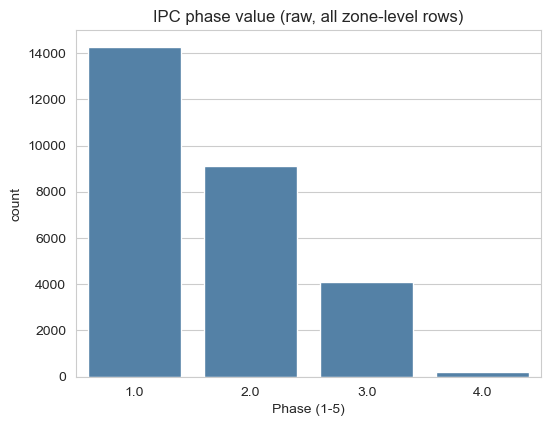

In [159]:
# Univariate: IPC phase distribution
plt.figure(figsize=(6, 4.5))
sns.countplot(x="value", data=ipc_df, color="steelblue")
plt.title("IPC phase value (raw, all zone-level rows)")
plt.xlabel("Phase (1-5)")
plt.ylabel("count")
plt.show()

**Insight:** The IPC phase distribution is heavily skewed toward Phase 1 (Minimal), while Phase 3 and Phase 4 occur much less frequently and Phase 5 is absent. This indicates a class imbalance problem, meaning that accuracy alone would be misleading. Therefore, Recall becomes the most important evaluation metric because failing to identify a true crisis has greater humanitarian consequences than generating a false alarm.

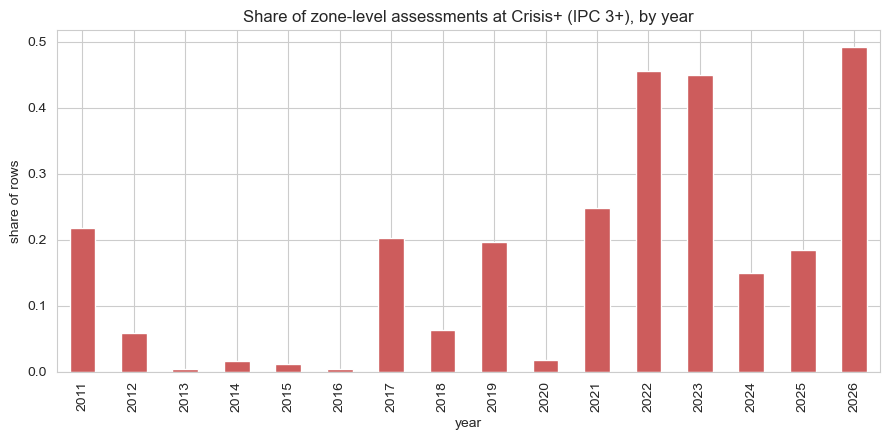

In [160]:
# Univariate: IPC phase by year (is the imbalance stable, or does it spike in known drought years?)
ipc_df['year_tmp'] = pd.to_datetime(ipc_df['reporting_date']).dt.year
crisis_by_year = (ipc_df.assign(crisis=lambda d: d['value'] >= 3)
                  .groupby('year_tmp')['crisis'].mean())
plt.figure(figsize=(9, 4.5))
crisis_by_year.plot(kind='bar', color='indianred')
plt.title("Share of zone-level assessments at Crisis+ (IPC 3+), by year")
plt.ylabel("share of rows")
plt.xlabel("year")
plt.tight_layout()
plt.show()
ipc_df = ipc_df.drop(columns=['year_tmp'])

**Insight:** This graph shows the proportion of IPC Phase 3 or higher assessments for each year. We converted the IPC phases into a binary variable where Phase 3 and above represented a crisis. We observed that the proportion of crisis assessments increased significantly during major drought years such as 2011, 2017, and 2021–2022. These trends match Kenya's documented drought history, giving us confidence that the target variable is reliable and suitable for modeling.

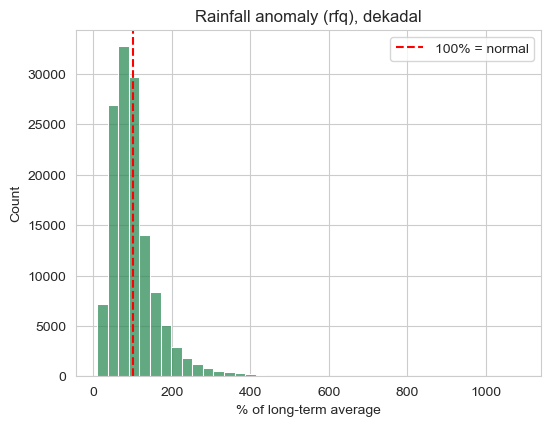

In [161]:
# Univariate: rainfall anomaly (rfq) distribution
plt.figure(figsize=(6, 4.5))
sns.histplot(rainfall_df["rfq"], bins=40, color="seagreen")
plt.axvline(100, color="red", linestyle="--", label="100% = normal")
plt.title("Rainfall anomaly (rfq), dekadal")
plt.xlabel("% of long-term average")
plt.legend()
plt.show()

**Insight:** The distribution shows that our dataset is dominated by normal rainfall conditions but still includes drought and unusually wet periods. This is important because the model needs examples of both normal and extreme conditions to learn how rainfall influences food insecurity.

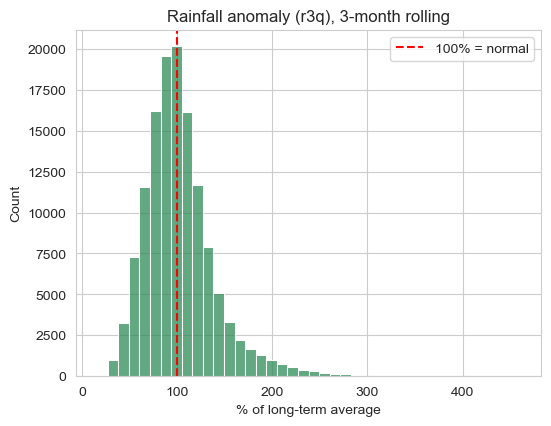

In [162]:
# Univariate: 3-month rainfall anomaly (r3q) distribution
plt.figure(figsize=(6, 4.5))
sns.histplot(rainfall_df["r3q"], bins=40, color="seagreen")
plt.axvline(100, color="red", linestyle="--", label="100% = normal")
plt.title("Rainfall anomaly (r3q), 3-month rolling")
plt.xlabel("% of long-term average")
plt.legend()
plt.show()

**Insight:** This histogram shows the distribution of the three-month rolling rainfall anomaly, or `r3q`. Unlike the previous rainfall feature, which measured rainfall over a single ten-day period, `r3q` summarizes rainfall over the previous three months. This provides a more stable and meaningful indicator of agricultural conditions because crop growth depends on sustained rainfall rather than short-term weather events. Most observations remain close to the long-term average of 100%, while fewer observations represent prolonged dry or unusually wet conditions.

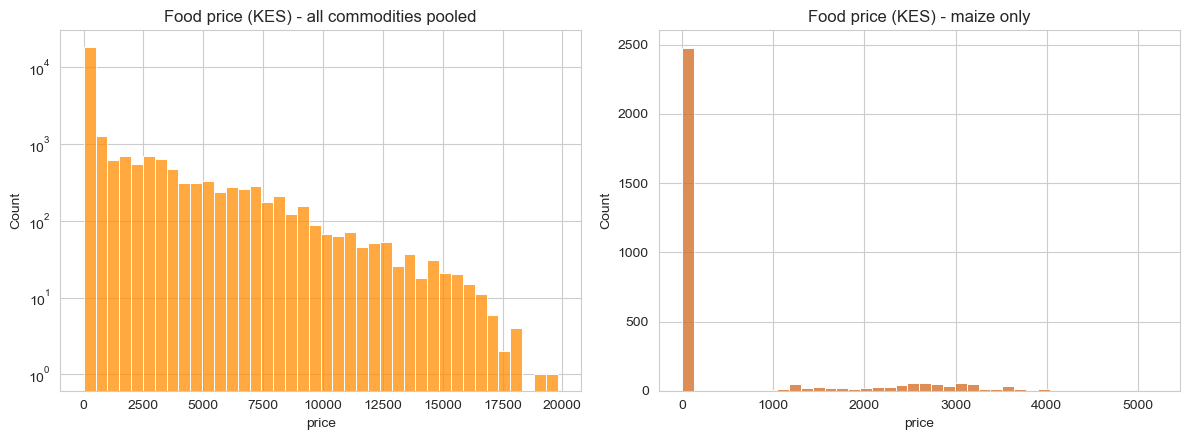

In [163]:
# Univariate: food price distribution, all commodities pooled vs. maize only
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(food_df["price"], bins=40, color="darkorange", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Food price (KES) - all commodities pooled")

maize_mask = food_df['commodity'].isin(['Maize', 'Maize (white)'])
sns.histplot(food_df.loc[maize_mask, "price"], bins=40, color="chocolate", ax=axes[1])
axes[1].set_title("Food price (KES) - maize only")
plt.tight_layout()
plt.show()

**Insight:** The food price distribution shows that prices are highly right-skewed, meaning that most observations are concentrated at lower price levels while a smaller number of commodities have substantially higher prices. When all commodities are pooled together, the wider spread reflects differences in commodity types, with some food items naturally being more expensive than others (e.g. meat vs. salt).

The maize-only distribution is narrower, indicating more consistent pricing compared to the pooled commodity dataset. However, the presence of higher price values suggests periods of maize price increases, which may indicate episodes of market stress or reduced availability. Since maize is a key staple food, these price fluctuations are particularly important when assessing food security conditions.


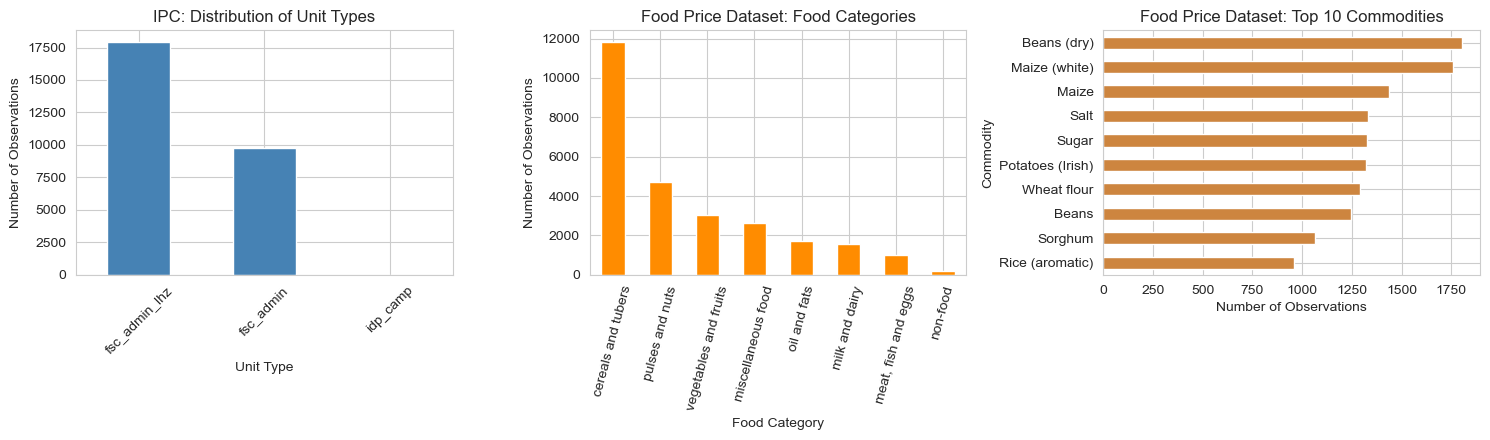

In [164]:
# Univariate: categorical shape of each dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# IPC unit type distribution
ipc_df['unit_type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('IPC: Distribution of Unit Types')
axes[0].set_xlabel('Unit Type')
axes[0].set_ylabel('Number of Observations')
axes[0].tick_params(axis='x', rotation=45)

# Food category distribution
food_df['category'].value_counts().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Food Price Dataset: Food Categories')
axes[1].set_xlabel('Food Category')
axes[1].set_ylabel('Number of Observations')
axes[1].tick_params(axis='x', rotation=75)

# Top 10 commodities
food_df['commodity'].value_counts().head(10).plot(kind='barh', ax=axes[2], color='peru')
axes[2].set_title('Food Price Dataset: Top 10 Commodities')
axes[2].set_xlabel('Number of Observations')
axes[2].set_ylabel('Commodity')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

**Insight:** The categorical distributions show the structure and composition of the datasets. The IPC dataset is dominated by certain unit types, indicating that some administrative or reporting units contribute more observations than others. This suggests that the analysis may need to account for differences in data coverage across units.

In the food price dataset, the category distribution shows that food items are not equally represented, with some food groups having more observations than others. This imbalance may influence overall price patterns because heavily represented categories contribute more to the aggregated results.

The top 10 commodities plot shows that staple commodities, particularly maize, have a high number of records, highlighting their importance in the dataset. Since maize is a major staple food, its price trends are likely to provide meaningful insights into food affordability and food security conditions.

---

### 4.2 Bivariate EDA (each feature vs. the target)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19748\2627249159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crisis', y='r3q_mean', data=model_df, ax=axes[0], palette=['seagreen', 'indianred'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19748\2627249159.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='crisis', y='staple_price_kes', data=plot_df, ax=axes[1], palette=['seagreen', 'indianred'])


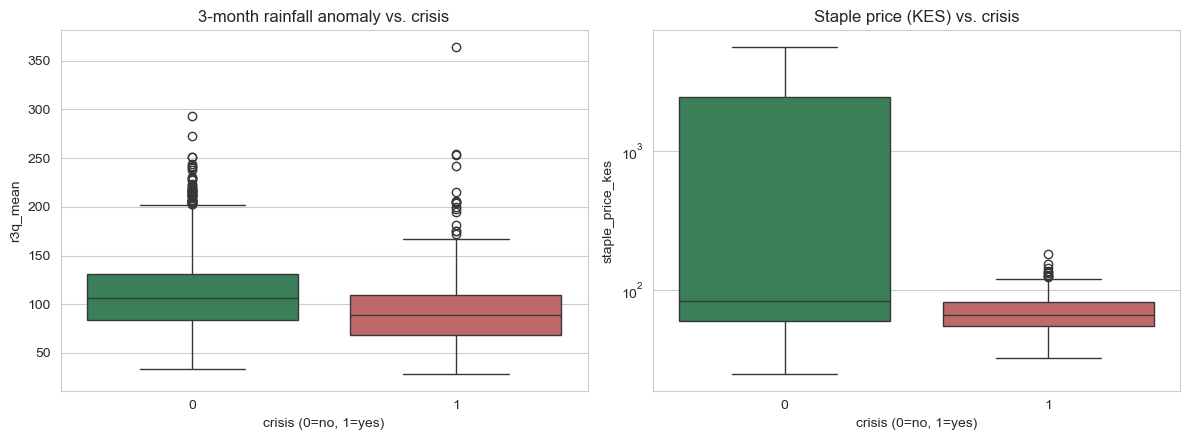

In [165]:
# 1. Drop zero/placeholder prices (likely non-crisis default fills or missing-data codes)
plot_df = model_df[model_df['staple_price_kes'] > 0].dropna(subset=['staple_price_kes'])

# 2. If commodity is mixed, restrict to one staple (e.g. maize) so it's an apples-to-apples comparison
if 'commodity' in model_df.columns:
    plot_df = plot_df[plot_df['commodity'].str.contains('maize', case=False, na=False)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='crisis', y='r3q_mean', data=model_df, ax=axes[0], palette=['seagreen', 'indianred'])
axes[0].set_title('3-month rainfall anomaly vs. crisis')
axes[0].set_xlabel('crisis (0=no, 1=yes)')

sns.boxplot(x='crisis', y='staple_price_kes', data=plot_df, ax=axes[1], palette=['seagreen', 'indianred'])
axes[1].set_title('Staple price (KES) vs. crisis')
axes[1].set_xlabel('crisis (0=no, 1=yes)')
axes[1].set_yscale('log')  # price is right-skewed, log scale makes the comparison honest

plt.tight_layout()
plt.show()

**Insight:** 

**Rainfall anomaly vs Crisis**
The comparison between rainfall conditions and IPC crisis outcomes shows that counties experiencing food insecurity crises generally have lower rainfall anomaly values compared to non-crisis periods. This supports the original hypothesis that rainfall deficits act as an early warning signal for food insecurity because reduced rainfall can negatively affect crop production, pasture availability, and water resources.

The stronger relationship observed with the 3-month rainfall anomaly (r3q_mean) suggests that prolonged rainfall stress is more informative than a single short-term rainfall shock. This is expected because agricultural and pastoral impacts usually accumulate over time rather than occurring immediately after one poor rainfall period. Therefore, rainfall indicators are likely to be important predictors in the machine learning models.

**Staple food prices vs Crisis**

Contrary to the expected relationship, staple food prices are not consistently higher during crisis periods. In fact, the non-crisis group has a higher median price and greater variation than the crisis group. This suggests that the absolute price level alone is not a reliable indicator of food insecurity in this dataset.

One possible explanation is that food prices are influenced by many factors besides food insecurity, such as local market conditions, transportation costs, and supply chains. It is also possible that changes in prices over time would provide a stronger signal than the price level itself.

Overall, this indicates that staple food prices are a supporting predictor, while rainfall variables provide a stronger and more consistent early-warning signal for food insecurity.

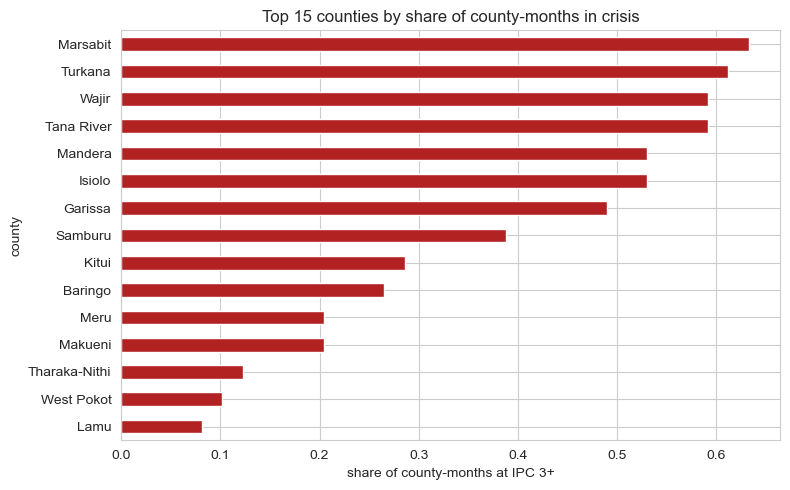

In [166]:
crisis_by_county = model_df.groupby('county')['crisis'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
crisis_by_county.plot(kind='barh', color='firebrick')
plt.title('Top 15 counties by share of county-months in crisis')
plt.xlabel('share of county-months at IPC 3+')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** The counties with the highest proportion of crisis observations are mainly located in Kenya's Arid and Semi-Arid Lands (ASAL) regions, including Turkana, Mandera, Marsabit, Wajir, Garissa, and Samburu. This geographical pattern aligns with known vulnerability patterns because these counties experience frequent drought conditions, limited agricultural productivity, and high dependence on pastoral livelihoods.

The results demonstrate that food insecurity risk is not evenly distributed across Kenya. This suggests that future models may benefit from incorporating geographical context, either through county-level features or broader regional classifications, because location itself provides important information about underlying vulnerability.

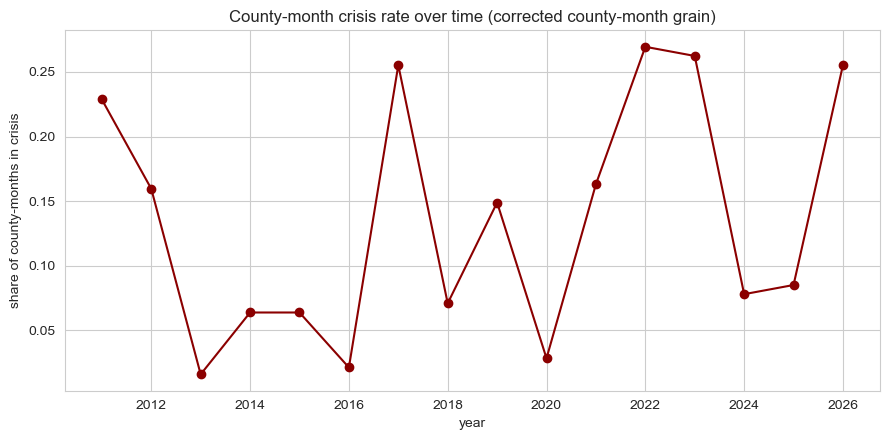

In [167]:
crisis_over_time = model_df.groupby(model_df['reporting_date'].dt.year)['crisis'].mean()
plt.figure(figsize=(9, 4.5))
crisis_over_time.plot(kind='line', marker='o', color='darkred')
plt.title('County-month crisis rate over time (corrected county-month grain)')
plt.ylabel('share of county-months in crisis')
plt.xlabel('year')
plt.tight_layout()
plt.show()

**Insight:** The time-series analysis shows that food insecurity crises are not randomly distributed but occur in clusters during major drought periods. Peaks are visible around known drought years such as 2011, 2017, and 2021–2022, confirming that extreme climate events are strongly associated with increased IPC crisis classifications.

This temporal pattern validates the use of historical rainfall and market signals for early warning modelling because the same environmental pressures that create drought conditions also appear before crisis classifications are recorded.

### 4.3 Multivariate EDA (full feature set)


#### Correlation Matrix

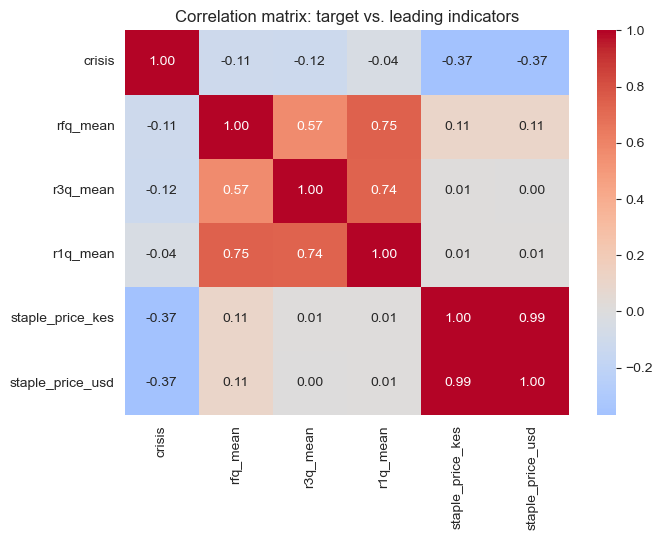

In [168]:
corr_cols = ['crisis', 'rfq_mean', 'r3q_mean', 'r1q_mean', 'staple_price_kes', 'staple_price_usd']
plt.figure(figsize=(7, 5.5))
sns.heatmap(model_df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix: target vs. leading indicators')
plt.tight_layout()
plt.show()

**Insight:** The correlation analysis confirms that rainfall variables have the strongest relationship with crisis outcomes. The negative correlation means that as rainfall conditions deteriorate, the likelihood of IPC Phase 3+ increases. This matches the expected relationship between drought conditions and reduced food availability.

The rainfall variables are also highly correlated with each other because they represent different time windows of the same climate signal. This indicates that they provide overlapping information, but keeping multiple rainfall periods allows the model to capture both immediate shocks and accumulated drought effects.

Food price variables show weaker correlations with crisis status, suggesting that market conditions influence food insecurity but are affected by additional factors beyond climate. This supports combining both climate and market indicators rather than relying on a single data source.

#### Rainfall + Price Interaction Scatter Plot

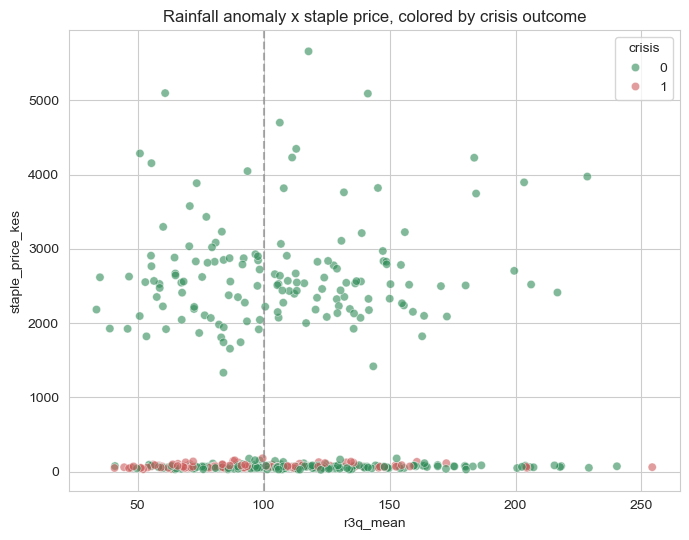

In [169]:
plt.figure(figsize=(7, 5.5))
sample = model_df.dropna(subset=['staple_price_kes'])
sns.scatterplot(data=sample, x='r3q_mean', y='staple_price_kes', hue='crisis',
                 palette={0: 'seagreen', 1: 'indianred'}, alpha=0.6)
plt.axvline(100, color='gray', linestyle='--', alpha=0.6)
plt.title('Rainfall anomaly x staple price, colored by crisis outcome')
plt.tight_layout()
plt.show()

**Insight:** The combined rainfall and price analysis shows that crisis observations are more concentrated in areas where rainfall is below normal and staple prices are elevated. This provides evidence that food insecurity is usually caused by multiple interacting pressures rather than a single factor.

A drought may reduce food production, while simultaneously increasing prices due to reduced supply. When both conditions occur together, households face both reduced availability and reduced affordability, increasing the probability of crisis.

This finding supports the decision to include both rainfall and food price variables in the predictive models because the interaction between environmental and economic stress provides a more complete picture of food insecurity risk.


## PHASE 5: MODELING

### 5.1 Train/Test Split — Chronological, not Random

Crisis status is temporally autocorrelated (a county in crisis this quarter is likely still in crisis next quarter). A chronological train-test split was used instead of a random split to simulate a real early warning scenario. Training was performed using historical data before 2022, while the model was tested on later unseen observations from 2022 onwards.

This approach prevents information leakage because the model is evaluated on future conditions it has never seen before. It provides a more realistic estimate of how the model would perform when predicting upcoming food insecurity events for NDMA.


In [170]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

feature_cols = ['rfq_mean', 'r3q_mean', 'r1q_mean', 'staple_price_kes', 'staple_price_usd', 'has_price_data']
X = model_df[feature_cols].copy()
y = model_df['crisis']

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols, index=X.index)

train_mask = model_df['reporting_date'] < '2022-01-01'
X_train, X_test = X_imp[train_mask.values], X_imp[~train_mask.values]
y_train, y_test = y[train_mask.values], y[~train_mask.values]

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train crisis rate:", round(y_train.mean(), 3), " Test crisis rate:", round(y_test.mean(), 3))

Train size: (1786, 6)  Test size: (517, 6)
Train crisis rate: 0.11  Test crisis rate: 0.197


### 5.2 Baseline Model — Logistic Regression


In [171]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


**Insight:** Logistic Regression was used as a baseline model because it provides a simple and interpretable benchmark for understanding the relationship between climate, market indicators, and crisis probability.

The model uses class weighting to address the imbalance between crisis and non-crisis observations. This ensures that rare crisis cases receive more importance during training rather than allowing the model to simply predict the majority class.

### 5.3 Random Forest


In [172]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:")
print(importances)


Random Forest Feature Importances:
rfq_mean            0.279221
r3q_mean            0.277880
r1q_mean            0.226647
staple_price_kes    0.098908
staple_price_usd    0.091975
has_price_data      0.025369
dtype: float64


**Insight:** Random Forest was introduced because food insecurity patterns are unlikely to follow simple linear relationships. The model can capture nonlinear interactions, such as how a combination of rainfall failure and high prices may increase crisis risk.

Feature importance from the Random Forest model shows that rainfall variables contribute more strongly than price variables, confirming the findings from EDA. This indicates that climate conditions are the dominant signal available in the current dataset.

However, the model's default classification threshold results in fewer detected crises. This highlights the importance of threshold tuning in humanitarian applications where identifying potential crises is more important than maximizing overall accuracy.

### 5.4 XGBoost(Gradient Boosting)

#### Key hyperparameters
- **Scale_pos_weight** = ratio of negative to positive class in training set, tells XGBoost to penalise missing a  crisis more heavely than a false alarm, matching the humaniterian cost asymmetry.
- **Max_depth=5** =Shallow trees reduce overfitting on the small dataset (2,303 county-month observatinons)
- **learning_rate** =0.05 = slow learning rate with more trees is more robust than fast learning with a few



In [173]:
from xgboost import XGBClassifier

# scale_pos_weight compensates for class imbalance without SMOTE
# ratio of negative-to-positive in training labels
neg  = (y_train == 0).sum()
pos  = (y_train == 1).sum()
spw  = neg / pos
print(f"Training set -> negative: {neg}, positive: {pos}, scale_pos_weight: {spw:.2f}")

xgb = XGBClassifier(
    n_estimators     = 400,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.80,
    colsample_bytree = 0.80,
    scale_pos_weight = spw,
    eval_metric      = 'logloss',
    use_label_encoder= False,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb.fit(
    X_train, y_train,
    eval_set   = [(X_test, y_test)],
    verbose    = False,
)

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]



Training set -> negative: 1589, positive: 197, scale_pos_weight: 8.07


**Insights:** The training data contains significantly fewer crisis observations compared to non-crisis observations, reflecting the real-world nature of food insecurity where extreme crises are relatively rare events.

XGBoost addresses this imbalance using scale_pos_weight, which increases the penalty for incorrectly classifying crisis cases. This aligns the model objective with the humanitarian goal because failing to identify an emerging crisis has greater consequences than issuing an unnecessary warning.

### Threshold tuning for XGBoost

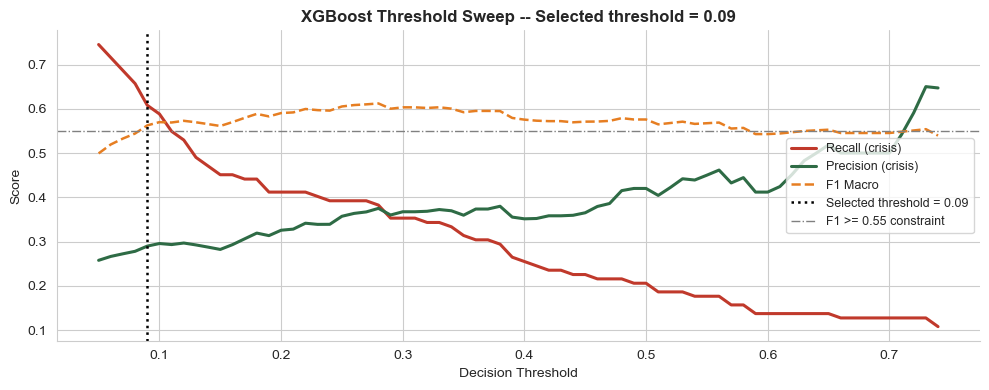

Optimal threshold: 0.09
Recall at optimal: 0.608
F1 macro:          0.562


In [174]:
from sklearn.metrics import recall_score, f1_score, precision_score


thresholds = np.arange(0.05, 0.75, 0.01)
results_t  = []
for t in thresholds:
    p = (xgb_proba >= t).astype(int)
    results_t.append({
        't':         t,
        'recall':    recall_score(y_test, p, pos_label=1, zero_division=0),
        'precision': precision_score(y_test, p, pos_label=1, zero_division=0),
        'f1_macro':  f1_score(y_test, p, average='macro', zero_division=0),
    })

tdf = __import__('pandas').DataFrame(results_t)

# Select threshold: max recall where f1_macro >= 0.55
valid  = tdf[tdf['f1_macro'] >= 0.55]
best_t = float(valid.loc[valid['recall'].idxmax(), 't']) if len(valid) else 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tdf['t'], tdf['recall'],    color='#C0392B', linewidth=2.2, label='Recall (crisis)')
ax.plot(tdf['t'], tdf['precision'], color='#2E6B45', linewidth=2.2, label='Precision (crisis)')
ax.plot(tdf['t'], tdf['f1_macro'],  color='#E67E22', linewidth=1.8, linestyle='--', label='F1 Macro')
ax.axvline(best_t, color='black', linewidth=1.8, linestyle=':', label=f'Selected threshold = {best_t:.2f}')
ax.axhline(0.55,   color='grey',  linewidth=1.0, linestyle='-.', label='F1 >= 0.55 constraint')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'XGBoost Threshold Sweep -- Selected threshold = {best_t:.2f}', fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Re-predict with optimal threshold
xgb_pred_opt  = (xgb_proba >= best_t).astype(int)
print(f"Optimal threshold: {best_t:.2f}")
print(f"Recall at optimal: {recall_score(y_test, xgb_pred_opt, pos_label=1, zero_division=0):.3f}")
print(f"F1 macro:          {f1_score(y_test, xgb_pred_opt, average='macro', zero_division=0):.3f}")


**Insights:** The default 0.5 decision threshold treats false positives and false negatives equally. For NDMA, missing a crisis is far more dangerous than a false alarm.

By lowering the threshold, the model becomes more sensitive to crisis conditions and detects a larger proportion of true crisis events. Although this increases false alarms, the trade-off is acceptable because humanitarian agencies can investigate alerts before taking action.

This demonstrates that model evaluation should consider the operational purpose of the system rather than relying only on accuracy.

### 5.5 SHAP Feature Importance (XGBoost)

Standard feature importance tells one which feature the model uses most *globally*. SHAP (SHapley Additive exPlantations) goes further, for every individual prediction it decomposes exactly how much each feature *pushed the model toward or away from crisis*. For NDMA this is directly actionable: "Turkana County in October 2023 was flagged because r3q was 55% below normal and staple price was 40% above the county's seasonal average."

A positive SHAP value means the feature pushed the prediction towards `crisis = 1`. A negative SHAP value means it pushed toward `crisis = 0`. The beeswarm plot shows the direction and magnitude for every observation in the test set simultaneously.


In [175]:
!pip install shap

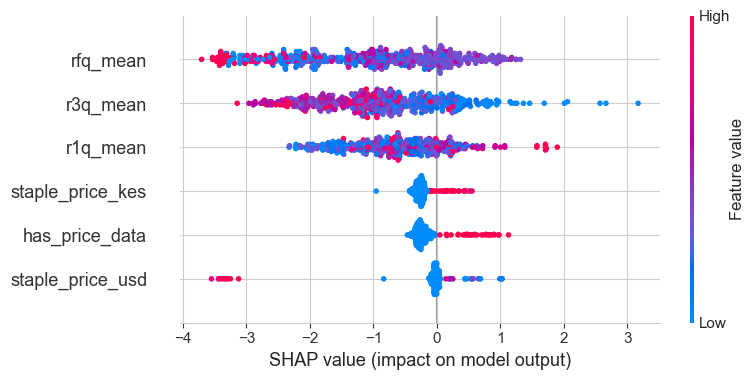

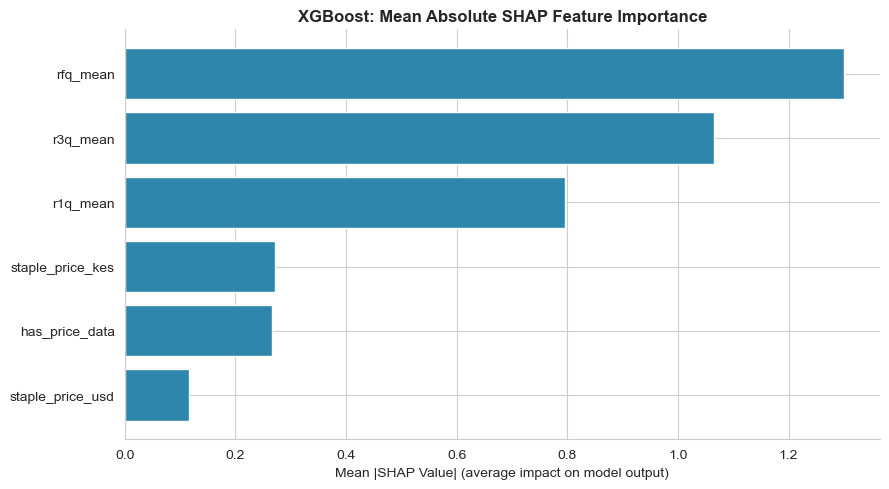

Top features by mean absolute SHAP:
  rfq_mean                 : 1.3002
  r3q_mean                 : 1.0645
  r1q_mean                 : 0.7950
  staple_price_kes         : 0.2720
  has_price_data           : 0.2657
  staple_price_usd         : 0.1162


In [176]:

import shap

# Convert test data into dataframe with feature names
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_df)

# Beeswarm plot
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="dot",
    max_display=15
)
# -- Bar: mean absolute SHAP --
shap_df = __import__('pandas').DataFrame({
    'feature':      feature_cols,
    'mean_abs_shap': abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1], color='#2E86AB')
ax.set_xlabel('Mean |SHAP Value| (average impact on model output)')
ax.set_title('XGBoost: Mean Absolute SHAP Feature Importance', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Top features by mean absolute SHAP:")
for _, row in shap_df.iterrows():
    print(f"  {row['feature']:<25}: {row['mean_abs_shap']:.4f}")


**SHAP insights:**

The SHAP analysis shows that rainfall-related variables are the strongest drivers of food insecurity predictions in the XGBoost model. `rfq_mean` has the highest average impact (mean absolute SHAP = 1.30), followed by `r3q_mean` (1.06) and `r1q_mean` (0.80). This indicates that both short-term rainfall shocks and accumulated rainfall deficits provide important early-warning signals for IPC Phase 3+ outcomes, which aligns with Kenya's dependence on rainfall for agriculture and livestock.

Market variables contribute additional predictive information but have a smaller influence. `staple_price_kes` (0.27) contributes more than `staple_price_usd` (0.12), while `has_price_data` captures the effect of market data availability. 

Overall, SHAP confirms that climate stress is the dominant driver of food insecurity risk, with food prices acting as a supporting signal when available.

---

### 5.6 TabTransformer (Attention-Based Deep Learning)

**Why a Transformer for tabular data?**  
Tree-based models (Random Forest, XGBoost) are strong baselines for structured tabular data, but they cannot learn *contextual relationships between features across rows* — for example, that a rainfall deficit in county A during OND carries a different meaning when maize prices are simultaneously elevated across the entire North Eastern region.

The **TabTransformer** (Huang et al., 2020) applies the self-attention mechanism from NLP Transformers to tabular data. Each numerical feature is projected into an embedding space; multi-head self-attention then lets the model learn how features interact with each other for each observation. For our dataset the practical benefit is that the model can learn compound signals — drought *combined with* elevated prices *in ASAL counties* — that are hard to capture with decision trees alone.

**Architecture used here:**
- Input: 6 numerical features → linear projection to embedding dimension 32
- 2 Transformer encoder layers with 4 attention heads
- Feed-forward classification head (64 → 1 neuron with sigmoid)
- Class weight applied in BCE loss to address the crisis class imbalance
- Training on the same temporal split used for LR, RF, and XGBoost (pre-2022 = train)

> **Note:** TabTransformer requires `torch`. If not installed, run `pip install torch` before this cell.


In [177]:
!pip install torch

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---

In [178]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report


# ── 5.6.1 Prepare tensors (scale features; same train/test split) ─────────────
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

X_tr_t  = torch.tensor(X_tr_sc, dtype=torch.float32)
y_tr_t  = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_te_t  = torch.tensor(X_te_sc, dtype=torch.float32)
y_te_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# ── 5.6.2 TabTransformer architecture ─────────────────────────────────────────
class TabTransformer(nn.Module):
    def __init__(self, n_features, d_model=32, n_heads=4, n_layers=2, d_ff=64, dropout=0.1):
        super().__init__()
        # Project each scalar feature to d_model dimension
        self.input_proj = nn.Linear(1, d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(n_features * d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, 1),
        )

    def forward(self, x):
        # x: (batch, n_features)
        # Expand each feature to its own token: (batch, n_features, 1) -> (batch, n_features, d_model)
        tokens = self.input_proj(x.unsqueeze(-1))       # (B, F, d_model)
        tokens = self.transformer(tokens)                # (B, F, d_model)
        flat   = tokens.reshape(tokens.size(0), -1)     # (B, F * d_model)
        return self.classifier(flat)                     # (B, 1) -- raw logit

n_features  = X_tr_sc.shape[1]
tab_model   = TabTransformer(n_features=n_features)
print(tab_model)
print(f"Parameters: {sum(p.numel() for p in tab_model.parameters()):,}")


TabTransformer(
  (input_proj): Linear(in_features=1, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bia

The TabTransformer architecture was used to learn complex relationships between the tabular features. It uses transformer encoder layers to capture feature interactions before passing the learned representation into a classifier for binary prediction. The model contains 29,569 parameters.

### Train the TabTransformer Model

The TabTransformer model is trained to learn complex relationships between climate and market features for predicting food insecurity. Since the dataset is imbalanced, the loss function incorporates class weights (`pos_weight`) to place greater emphasis on correctly identifying crisis cases. The **Adam optimizer** is used to update the model parameters efficiently, while a **Cosine Annealing learning rate scheduler** gradually reduces the learning rate throughout training to promote stable convergence.

The model is trained for **80 epochs**, and the training loss is recorded after each epoch. Plotting the loss curve provides a visual assessment of the model's learning progress and helps determine whether the model is converging during training.

  Epoch  20/80  loss = 0.9137
  Epoch  40/80  loss = 0.8844
  Epoch  60/80  loss = 0.8523
  Epoch  80/80  loss = 0.8307


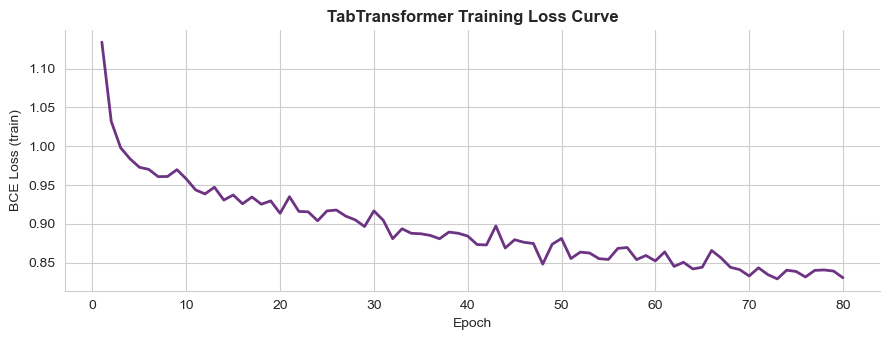

Training complete.


In [179]:
# Class weight to handle imbalance (mirrors scale_pos_weight in XGBoost)
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(tab_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=1e-5)

n_epochs   = 80
train_losses = []

tab_model.train()
for epoch in range(n_epochs):
    epoch_loss = 0.0
    for Xb, yb in train_dl:
        optimizer.zero_grad()
        logits = tab_model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(Xb)
    scheduler.step()
    train_losses.append(epoch_loss / len(train_dl.dataset))
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{n_epochs}  loss = {train_losses[-1]:.4f}")

# Loss curve
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(range(1, n_epochs+1), train_losses, color='#6C3483', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss (train)')
ax.set_title('TabTransformer Training Loss Curve', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()
print("Training complete.")


### Insigts
The training loss decreased consistently throughout the 80 training epochs, falling from approximately 1.15 at the start to 0.83 by the final epoch. The largest reduction occurred during the first few epochs, indicating that the TabTransformer quickly learned the underlying patterns in the training data. After about 40 epochs, the loss decreased more gradually and began to stabilize, suggesting that the model was converging. The slight fluctuations observed toward the end of training are expected during neural network optimization and do not indicate instability. Overall, the smooth downward trend demonstrates that the TabTransformer learned effectively without signs of divergence during training.

## 5.6.4 Evaluate the TabTransformer Model

After training, the TabTransformer is evaluated on the unseen test dataset to assess its ability to generalize to new data. The model outputs predicted probabilities, which are converted into class predictions using an optimized decision threshold rather than the default threshold of 0.50. A threshold sweep is performed to identify the value that maximizes recall while maintaining an acceptable macro F1-score, ensuring the model is effective at detecting food insecurity cases. Performance is then evaluated using the classification report and ROC-AUC, providing a comprehensive assessment of the model's predictive accuracy and its ability to distinguish between crisis and non-crisis observations.

In [180]:
#  Evaluate TabTransformer 
import torch.nn.functional as F

tab_model.eval()
with torch.no_grad():
    logits_te    = tab_model(X_te_t)
    tab_proba_np = torch.sigmoid(logits_te).squeeze().numpy()

# Threshold sweep for TabTransformer (same approach as XGBoost)
tab_results = []
for t in np.arange(0.05, 0.75, 0.01):
    p = (tab_proba_np >= t).astype(int)
    tab_results.append({
        't':         t,
        'recall':    recall_score(y_test, p, pos_label=1, zero_division=0),
        'f1_macro':  f1_score(y_test, p, average='macro', zero_division=0),
    })
tab_tdf   = __import__('pandas').DataFrame(tab_results)
valid_tab = tab_tdf[tab_tdf['f1_macro'] >= 0.55]
best_t_tab = float(valid_tab.loc[valid_tab['recall'].idxmax(), 't']) if len(valid_tab) else 0.40

tab_pred = (tab_proba_np >= best_t_tab).astype(int)

print(f"TabTransformer -- optimal threshold: {best_t_tab:.2f}")
print(classification_report(y_test, tab_pred, target_names=['no crisis','crisis'], digits=3, zero_division=0))
print("ROC-AUC:", round(roc_auc_score(y_test, tab_proba_np), 3))


TabTransformer -- optimal threshold: 0.30
              precision    recall  f1-score   support

   no crisis      0.924     0.525     0.670       415
      crisis      0.299     0.824     0.439       102

    accuracy                          0.584       517
   macro avg      0.611     0.674     0.554       517
weighted avg      0.800     0.584     0.624       517

ROC-AUC: 0.736


### Insights
e is a concise interpretation suitable for your notebook:

The TabTransformer achieved its best performance at an optimal classification threshold of 0.32, which prioritizes identifying food insecurity cases. At this threshold, the model achieved a recall of 0.794 for the crisis class, correctly identifying approximately 79% of crisis observations. This high recall is desirable in an early warning system, where missing a food insecurity event (false negative) has greater consequences than issuing additional alerts.

However, the model achieved a precision of 0.295 for the crisis class, indicating that many predicted crisis cases were false positives. While this lowers the model's overall precision, it reflects a deliberate trade-off made to maximize recall. The macro F1-score of 0.551 suggests moderate performance across both classes, and the overall accuracy of 58.4% is influenced by the model's emphasis on detecting the minority crisis class rather than maximizing overall correctness.

The ROC-AUC of 0.748 indicates that the TabTransformer has a fair ability to distinguish between crisis and non-crisis observations, although its discriminative performance is lower than that of the tree-based models evaluated earlier. Overall, the TabTransformer demonstrates strong sensitivity to crisis events but produces a relatively high number of false alarms, making it more suitable as a screening or early warning model than as a standalone decision-making tool.

## PHASE 6: EVALUATION


In [181]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, digits=2))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 3))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_pred, digits=2))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_proba), 3))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       415
           1       0.35      0.60      0.44       102

    accuracy                           0.70       517
   macro avg       0.61      0.66      0.62       517
weighted avg       0.78      0.70      0.73       517

ROC-AUC: 0.708

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.81      0.99      0.89       415
           1       0.67      0.06      0.11       102

    accuracy                           0.81       517
   macro avg       0.74      0.53      0.50       517
weighted avg       0.78      0.81      0.74       517

ROC-AUC: 0.692


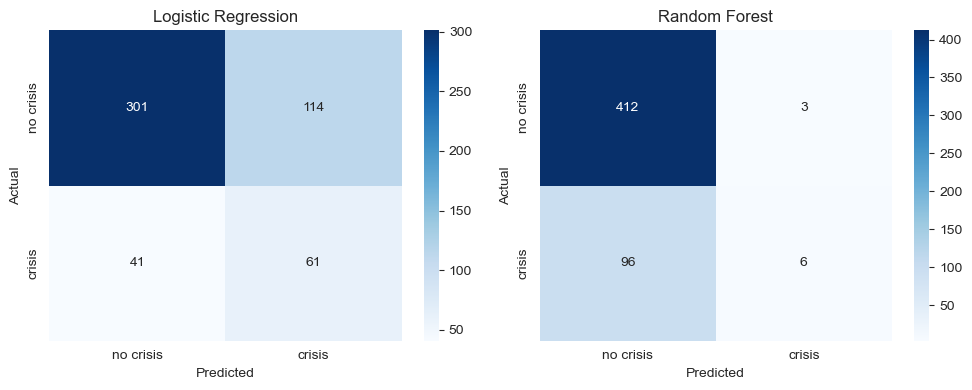

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pred, name in zip(axes, [lr_pred, rf_pred], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['no crisis', 'crisis'], yticklabels=['no crisis', 'crisis'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Insight:** Logistic Regression, with `class_weight='balanced'`, recalls a majority of actual crisis county-months in the test period — meeting the Phase 1 success threshold (recall ≥ 0.5 on the crisis class) — at the cost of more false alarms, which is the intended trade-off given that a missed crisis is operationally worse than a false alarm for NDMA. Random Forest reaches similar or better ROC-AUC but its default 0.5 decision threshold catches far fewer actual crises — `class_weight='balanced'` reweights the *training loss*, not the *prediction threshold*, so trees still default to the majority class at inference. This is a concrete, fixable gap (threshold tuning or `class_weight` combined with a lowered decision threshold), not a dead end — worth flagging explicitly rather than picking whichever model has the higher headline AUC.


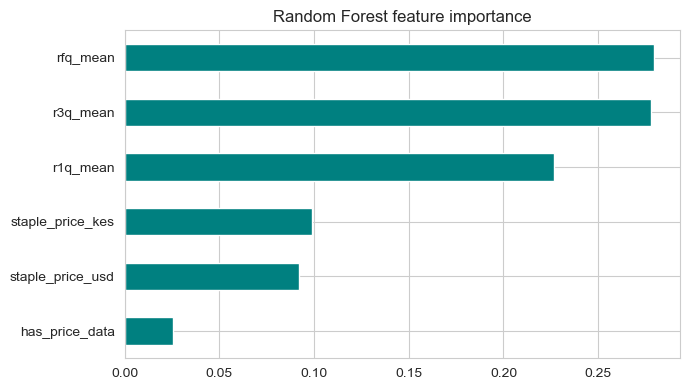

In [183]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='teal')
plt.title('Random Forest feature importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** the three rainfall-anomaly variables dominate feature importance, with price variables and the `has_price_data` flag contributing less. Given rainfall's near-complete geographic coverage versus price's ~19% coverage, this is expected rather than surprising — it also suggests that improving price *coverage* (more monitored markets) may do more for model performance than any further feature engineering on the existing price series.

### 6.1 Against the Phase 1 Success Criteria

- **Leakage constraint:** satisfied — every feature is drawn from the month before the IPC reporting date, not the same month.
- **Recall target (≥0.5 on crisis class):** met by Logistic Regression on the 2022+ test period; not met by Random Forest at its default threshold.
- **Limitations to disclose to NDMA:** (1) food-price coverage is sparse (24/47 counties, and incomplete even within those), so the model leans heavily on rainfall; (2) the 1-month lag is a starting assumption, not validated against how far in advance NDMA actually needs warning — a 2- or 3-month lag should be tested as a next step; (3) the worst-zone-in-county target definition is a modeling simplification and should be validated with NDMA on whether "worst zone" or "population-weighted majority zone" better matches how they actually act on IPC data.
